<a href="https://colab.research.google.com/github/yashbavkar26/23CE279/blob/main/NoisePollution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14096  100 14096    0     0   110k      0 --:--:-- --:--:-- --:--:--  111k
📂 Please upload a WAV file


Saving train-horn-337875.wav to train-horn-337875 (3).wav

🎧 Detected: Music
🔊 Decibel Level: 75.12999725341797 dB
📊 Status: 🚨 Harmful


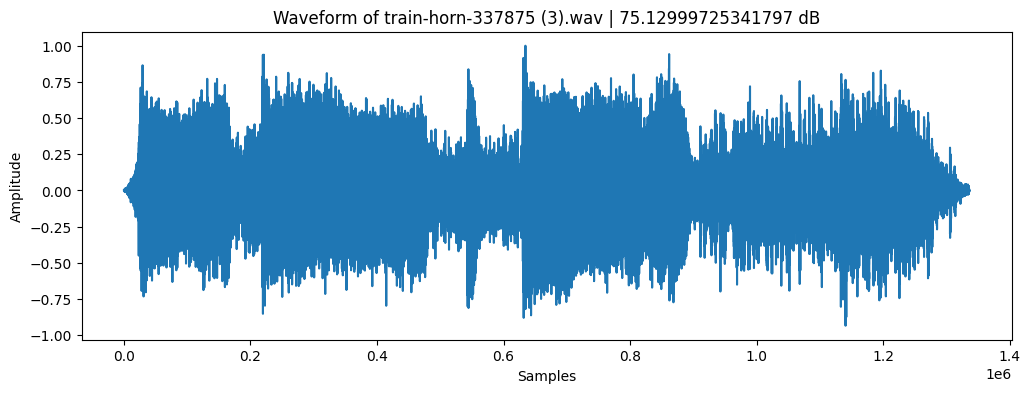

In [9]:
# Install dependencies
!pip install tensorflow tensorflow-hub numpy matplotlib -q

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from google.colab import files
import csv

# Load YAMNet model from TF Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Download the class map file
!curl -O https://raw.githubusercontent.com/tensorflow/models/master/research/audioset/yamnet/yamnet_class_map.csv

# Load the class map
with open('yamnet_class_map.csv') as csvfile:
    reader = csv.reader(csvfile)
    # Skip header
    next(reader)
    class_names = [row[2] for row in reader]


# Function to compute decibel level
def calculate_db(audio):
    rms = np.sqrt(np.mean(audio**2))
    db = 20 * np.log10(rms + 1e-6)+90  # avoid log(0)
    return round(db, 2)

# Function to classify sound
def classify_sound(audio):
    scores, embeddings, spectrogram = yamnet_model(audio)
    # class_names = yamnet_model.class_name # Removed the incorrect line
    top_class = class_names[scores.numpy().mean(axis=0).argmax()]
    return top_class

# ---- Upload file ----
print("📂 Please upload a WAV file")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ---- Load audio ----
sr, wav_data = wavfile.read(filename)

# Convert to mono
if wav_data.ndim > 1:
    wav_data = np.mean(wav_data, axis=1)

# Convert to float32 between -1.0 and 1.0
wav_data = wav_data.astype(np.float32)
if np.max(np.abs(wav_data)) > 0:
    wav_data = wav_data / np.max(np.abs(wav_data))

# ---- Run classification ----
db_level = calculate_db(wav_data)
sound_type = classify_sound(wav_data)

# WHO threshold check
if db_level < 55:
    status = "✅ Safe"
elif db_level < 70:
    status = "⚠️ Moderate"
else:
    status = "🚨 Harmful"

print(f"\n🎧 Detected: {sound_type}")
print(f"🔊 Decibel Level: {db_level} dB")
print(f"📊 Status: {status}")

# Optional: visualize waveform
plt.figure(figsize=(12,4))
plt.plot(wav_data)
plt.title(f"Waveform of {filename} | {db_level} dB")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [10]:
# Install PortAudio
!apt-get update -qq
!apt-get install libportaudio2 -y

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libportaudio2 is already the newest version (19.6.0-1.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
